In [28]:
import xarray as xr
import os
import numpy as np

import rasterio
from rasterio.shutil import copy

from matplotlib import pyplot as plt

from spectral.io import envi

from isofit.utils.skyview import skyview 

from scipy.ndimage import binary_dilation

%matplotlib widget

In [6]:
home = '/store/carroll/col/data/2018/'

fp = os.path.join(home, 'raw/dsm_mosaic_min_phase_me.tif') # https://data.ess-dive.lbl.gov/view/doi%3A10.15485%2F1617203

out_folder = os.path.join(home, 'skyview')
os.makedirs(out_folder, exist_ok=True)

In [5]:
# confirm crs
ds = xr.open_dataset(fp, engine='rasterio')
ds.spatial_ref.projected_crs_name

'WGS 84 / UTM zone 13N'

In [17]:
# first convert .tif to envi format

fp_out = os.path.join(out_folder, 'dsm')
with rasterio.open(fp) as src:
    copy(src, fp_out, driver="ENVI")

In [14]:
# visualize dsm
fp = os.path.join(out_folder, 'dsm.hdr')
dsm = envi.open(fp).open_memmap()[...,0]
dsm.shape

(26450, 21640)

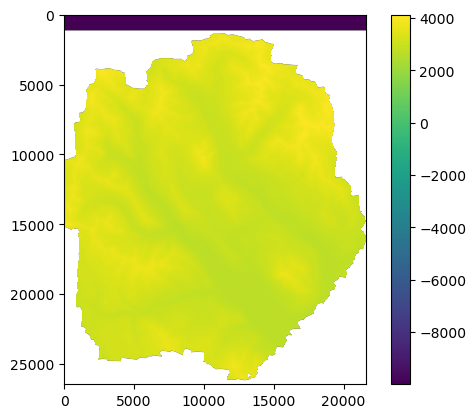

In [12]:
fig = plt.figure()
plt.imshow(dsm)
plt.colorbar()
plt.show()

In [20]:
# create a mask for good / bad skyview factor values
mask = dsm.copy()
mask[mask>=0] = 1
mask[mask==-9999] = 0
mask[np.isnan(mask)] = 0

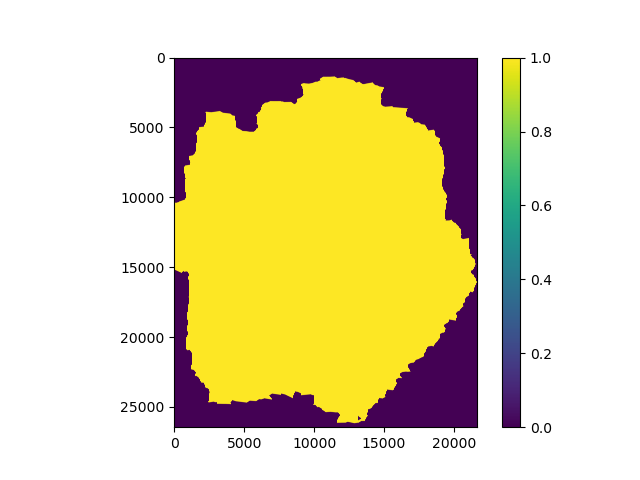

In [29]:
fig = plt.figure()
plt.imshow(mask)
plt.colorbar()
plt.show()

In [25]:
# now buffer in 1000 px from any px==0

zero_mask = (mask == 0)
dilated = binary_dilation(zero_mask, iterations=1000)
dilated.shape

(26450, 21640)

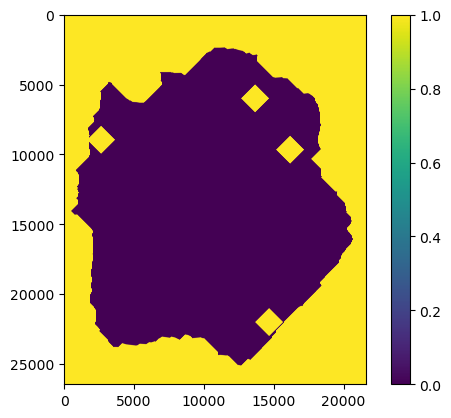

In [26]:
fig = plt.figure()
plt.imshow(dilated)
plt.colorbar()
plt.show()

In [1]:
# create the larger skyview factor file -
# sbatch /home/carroll/slurm/skyview.sh